# PAPIT Throughput Evaluation — value_free scoring

**What this notebook benchmarks:**
The original PAPIT pipeline adds ~110 ms per image from the CLIP scoring step
(visual_projection over 576 patches). `scoring_mode="value_free"` captures
the v_proj outputs *during the existing ViT forward pass* at zero extra cost,
dropping the overhead to ~8 ms (text encoding only).

**Four variants timed per image:**
- `unpruned`: full N=576 tokens (baseline)
- `papit`: GradCAM/cosine hybrid scoring — original PAPIT (~110 ms overhead)
- `value_free`: v_proj cosine scoring, free during ViT forward (~8 ms overhead)
- `random`: no scoring at all (lower bound on overhead)

**Run top-to-bottom in Google Colab with T4 or L4 GPU.**

In [1]:
# Cell 1 — Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print('Drive mounted.')
except Exception:
    IN_COLAB = False
    print('Not in Colab — running locally.')

Mounted at /content/drive
Drive mounted.


In [2]:
# Cell 2 — Configuration
from pathlib import Path

REPO_URL    = 'https://github.com/ch218-collab/comp646.git'
PROJECT_DIR = Path('/content/PAPIT')
DRIVE_ROOT  = Path('/content/drive/MyDrive')
OUTPUT_ROOT = DRIVE_ROOT / 'papit_runs' / 'throughput_eval'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

IMAGE_DIR  = str(DRIVE_ROOT / 'papit_eval_images')
MAX_IMAGES = 100

RETENTION_GRID  = [1.0, 0.75, 0.5, 0.25]
WARMUP_RUNS     = 3
TIMED_RUNS      = 5
ANCHOR_STRATEGY = 'global_mean'
MAX_NEW_TOKENS  = 32
BENCH_QUESTION  = 'What is in the image?'

LLAVA_MODEL_ID  = 'llava-hf/llava-1.5-7b-hf'
CLIP_MODEL_ID   = 'openai/clip-vit-large-patch14'

# USE_4BIT=True  for T4 (16 GB).  False for L4 / A100 / H100.
USE_4BIT = True
GPU_TAG  = ''

AUTO_BOOTSTRAP = True
BOOTSTRAP_SIZE = (336, 336)

print('OUTPUT_ROOT (base) =', OUTPUT_ROOT)
print('MAX_IMAGES         =', MAX_IMAGES)
print('RETENTION_GRID     =', RETENTION_GRID)
print('WARMUP_RUNS        =', WARMUP_RUNS)
print('TIMED_RUNS         =', TIMED_RUNS)
print('MAX_NEW_TOKENS     =', MAX_NEW_TOKENS)
print('USE_4BIT           =', USE_4BIT)

OUTPUT_ROOT (base) = /content/drive/MyDrive/papit_runs/throughput_eval
MAX_IMAGES         = 100
RETENTION_GRID     = [1.0, 0.75, 0.5, 0.25]
WARMUP_RUNS        = 3
TIMED_RUNS         = 5
MAX_NEW_TOKENS     = 32
USE_4BIT           = True


In [3]:
# Cell 3 — Clone / pull repo and install
import os, subprocess, sys

def run(cmd, cwd=None):
    print('$', ' '.join(cmd))
    subprocess.run(cmd, cwd=cwd, check=True)

if PROJECT_DIR.exists():
    run(['git', 'pull'], cwd=str(PROJECT_DIR))
else:
    run(['git', 'clone', REPO_URL, str(PROJECT_DIR)])

os.chdir(PROJECT_DIR)
run([sys.executable, '-m', 'pip', 'install', '-e', '.[llava]', '-q'])
run([sys.executable, '-m', 'pip', 'install', '-U', 'bitsandbytes>=0.46.1', '-q'])

print('\nInstall complete. CWD:', PROJECT_DIR)

$ git clone https://github.com/ch218-collab/comp646.git /content/PAPIT
$ /usr/bin/python3 -m pip install -e .[llava] -q
$ /usr/bin/python3 -m pip install -U bitsandbytes>=0.46.1 -q

Install complete. CWD: /content/PAPIT


In [4]:
# Cell 4 — GPU sanity check + feature check
import torch
assert torch.cuda.is_available(), 'No GPU detected. Go to Runtime > Change runtime type > GPU.'
props = torch.cuda.get_device_properties(0)
print('CUDA device :', torch.cuda.get_device_name(0))
print('VRAM (GB)   :', round(props.total_memory / 1e9, 1))
print('SM count    :', props.multi_processor_count)

# Verify this repo has the value_free feature
from papit.core.config import PAPITConfig
assert 'scoring_mode' in PAPITConfig.__dataclass_fields__, (
    'scoring_mode not found in PAPITConfig — repo may not have the latest commit. '
    'Try: git -C /content/PAPIT pull')
print('\nFeature check PASSED: scoring_mode present in PAPITConfig')
print('PAPITConfig fields:', list(PAPITConfig.__dataclass_fields__.keys()))

CUDA device : Tesla T4
VRAM (GB)   : 15.6
SM count    : 40

Feature check PASSED: scoring_mode present in PAPITConfig
PAPITConfig fields: ['model_id', 'retention_ratio', 'anchor_strategy', 'device', 'scoring_mode']


In [5]:
# Cell 5 — Prepare image list (bootstrap synthetic images if needed)
import random
from PIL import Image
import numpy as np

img_dir = Path(IMAGE_DIR)
img_dir.mkdir(parents=True, exist_ok=True)

exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
image_paths = sorted(p for p in img_dir.rglob('*') if p.suffix.lower() in exts)

if len(image_paths) < MAX_IMAGES:
    if AUTO_BOOTSTRAP:
        need = MAX_IMAGES - len(image_paths)
        print(f'Bootstrapping {need} synthetic {BOOTSTRAP_SIZE} images ...')
        rng = random.Random(42)
        for i in range(need):
            arr = np.array([[[rng.randint(0, 255) for _ in range(3)]
                              for _ in range(BOOTSTRAP_SIZE[1])]
                             for _ in range(BOOTSTRAP_SIZE[0])], dtype=np.uint8)
            p = img_dir / f'synth_{i:04d}.jpg'
            Image.fromarray(arr).save(p)
            image_paths.append(p)
        print(f'  Done. Total images: {len(image_paths)}')
    else:
        raise FileNotFoundError(
            f'Only {len(image_paths)} images in {img_dir}; need {MAX_IMAGES}.')

random.seed(42)
image_paths = random.sample(image_paths, MAX_IMAGES)
print(f'Using {len(image_paths)} images for benchmarking.')

Using 100 images for benchmarking.


In [6]:
# Cell 6 — Load LLaVA + PAPIT runner
import sys, subprocess

if USE_4BIT:
    try:
        import bitsandbytes as _bnb
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-U',
                        'bitsandbytes>=0.46.1', '-q'], check=True)
        import bitsandbytes as _bnb
    print(f'bitsandbytes version: {_bnb.__version__}')

import torch
from papit.core.config import PAPITConfig
from papit.benchmark.llava_runner import _ExtendedRunner

# Auto-detect GPU tag
if not GPU_TAG:
    raw = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'
    GPU_TAG = (raw.replace('NVIDIA ', '').replace('Tesla ', '')
                  .split('-')[0].split(' ')[0].strip())
    print(f'GPU_TAG auto-set to: {GPU_TAG!r}  (from: {raw!r})')

# Save to a GPU-specific subfolder named with _vf suffix to distinguish from prior runs
OUTPUT_ROOT = OUTPUT_ROOT.parent / f'{GPU_TAG}_vf'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Saving outputs to: {OUTPUT_ROOT}')

quant_cfg = None
if USE_4BIT:
    from transformers import BitsAndBytesConfig
    quant_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
    )
    print('Quantization: 4-bit NF4  <- T4 mode')
else:
    print('Quantization: fp16  <- L4 / A100 / H100 mode')

cfg = PAPITConfig(
    retention_ratio=0.5,
    anchor_strategy=ANCHOR_STRATEGY,
    device='cuda',
    scoring_mode='gradcam',   # default; overridden per variant in timing loop
)

runner = _ExtendedRunner(
    llava_model_id=LLAVA_MODEL_ID,
    clip_model_id=CLIP_MODEL_ID,
    config=cfg,
    device='cuda',
    quantization_config=quant_cfg,
)
print('Runner ready.')

bitsandbytes version: 0.49.2
GPU_TAG auto-set to: 'T4'  (from: 'Tesla T4')
Saving outputs to: /content/drive/MyDrive/papit_runs/T4_vf
Quantization: 4-bit NF4  <- T4 mode


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Runner ready.


In [7]:
# Cell 7 — Warmup (both scoring modes + unpruned)
import time
from PIL import Image as PILImage

print(f'Warming up ({WARMUP_RUNS} runs on first image) ...')
warmup_img = PILImage.open(image_paths[0]).convert('RGB')

for _ in range(WARMUP_RUNS):
    runner.config.retention_ratio = 0.5

    runner.config.scoring_mode = 'gradcam'
    runner.generate(warmup_img, BENCH_QUESTION, max_new_tokens=MAX_NEW_TOKENS)

    runner.config.scoring_mode = 'value_free'
    runner.generate(warmup_img, BENCH_QUESTION, max_new_tokens=MAX_NEW_TOKENS)

    runner.generate_unpruned(warmup_img, BENCH_QUESTION, max_new_tokens=MAX_NEW_TOKENS)

runner.config.scoring_mode = 'gradcam'
torch.cuda.synchronize()
print('Warmup complete.')

Warming up (3 runs on first image) ...
Warmup complete.


In [8]:
# Cell 7b — Component profiling
import numpy as np

probe_img = PILImage.open(image_paths[0]).convert('RGB')
N_PROBE = 5

# A) ViT forward pass cost
vit_times = []
with torch.no_grad():
    inputs = runner.processor(
        images=probe_img, text=runner._format_prompt(BENCH_QUESTION), return_tensors='pt')
    pv = inputs['pixel_values'].to(runner.device)
    for _ in range(N_PROBE):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        runner._extract_vit_features(pv)
        torch.cuda.synchronize()
        vit_times.append(time.perf_counter() - t0)
vit_ms = np.mean(vit_times) * 1000

# B) CLIP text encoding cost (same for both scoring modes)
clip_times = []
clip_inputs = runner.clip_processor(
    text=[BENCH_QUESTION], return_tensors='pt', padding=True).to(runner.device)
for _ in range(N_PROBE):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        runner.text_model(**clip_inputs)
    torch.cuda.synchronize()
    clip_times.append(time.perf_counter() - t0)
clip_ms = np.mean(clip_times) * 1000

# C) Full unpruned latency
total_times = []
for _ in range(N_PROBE):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    runner.generate_unpruned(probe_img, BENCH_QUESTION, max_new_tokens=MAX_NEW_TOKENS)
    torch.cuda.synchronize()
    total_times.append(time.perf_counter() - t0)
unpruned_ms = np.mean(total_times) * 1000
llm_mlp_ms = unpruned_ms - vit_ms

theoretical_max = unpruned_ms / (vit_ms + clip_ms + 0.25 * llm_mlp_ms)

print('=' * 60)
print('  PIPELINE COMPONENT BREAKDOWN')
print('=' * 60)
print(f'  ViT forward (all 576 patches)   : {vit_ms:>7.1f} ms  ({100*vit_ms/unpruned_ms:.0f}%)')
print(f'  LLM + MLP projector             : {llm_mlp_ms:>7.1f} ms  ({100*llm_mlp_ms/unpruned_ms:.0f}%)')
print(f'  Total unpruned                  : {unpruned_ms:>7.1f} ms')
print(f'  CLIP text encoding (overhead)   : {clip_ms:>6.1f} ms')
print(f'  Theoretical max speedup k=0.25  : {theoretical_max:.2f}x')
print()
print('  value_free overhead = only CLIP text encoding (~clip_ms above)')
print('  papit (GradCAM) overhead = ~110ms visible as papit-random gap')

  PIPELINE COMPONENT BREAKDOWN
  ViT forward (all 576 patches)   :   105.3 ms  (10%)
  LLM + MLP projector             :   930.5 ms  (90%)
  Total unpruned                  :  1035.7 ms
  CLIP text encoding (overhead)   :   18.2 ms
  Theoretical max speedup k=0.25  : 2.91x

  value_free overhead = only CLIP text encoding (~clip_ms above)
  papit (GradCAM) overhead = ~110ms visible as papit-random gap


In [9]:
# Cell 8 — End-to-end throughput benchmark
#
# Variants per (image, k):
#   unpruned    — full 576 tokens
#   papit       — GradCAM/cosine hybrid scoring (original, ~110ms overhead)
#   value_free  — v_proj cosine scoring, zero extra forward pass (~8ms overhead)
#   random      — no scoring (best-case latency lower bound)

import pandas as pd
from tqdm import tqdm

records = []

for img_path in tqdm(image_paths, desc='Images'):
    img_pil = PILImage.open(img_path).convert('RGB')

    # Unpruned baseline
    runner.config.retention_ratio = 1.0
    runner.config.scoring_mode = 'gradcam'
    base_times = []
    for _ in range(TIMED_RUNS):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        runner.generate_unpruned(img_pil, BENCH_QUESTION, max_new_tokens=MAX_NEW_TOKENS)
        torch.cuda.synchronize()
        base_times.append(time.perf_counter() - t0)
    records.append(dict(image=img_path.name, variant='unpruned',
                        retention_ratio=1.0, times=base_times))

    for k in [r for r in RETENTION_GRID if r < 1.0]:
        runner.config.retention_ratio = k

        # Get N to compute k_int for random
        with torch.no_grad():
            inputs = runner.processor(
                images=img_pil,
                text=runner._format_prompt(BENCH_QUESTION),
                return_tensors='pt')
            pv = inputs['pixel_values'].to(runner.device)
            pf_proj, _, _v = runner._extract_vit_features(pv)
            N = pf_proj.shape[0]
        k_int = max(1, int(round(N * k)))

        # PAPIT — GradCAM/cosine hybrid (original)
        runner.config.scoring_mode = 'gradcam'
        papit_times = []
        for _ in range(TIMED_RUNS):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            runner.generate(img_pil, BENCH_QUESTION, max_new_tokens=MAX_NEW_TOKENS)
            torch.cuda.synchronize()
            papit_times.append(time.perf_counter() - t0)
        records.append(dict(image=img_path.name, variant='papit',
                            retention_ratio=k, times=papit_times))

        # value_free — v_proj cosine (new, zero extra overhead)
        runner.config.scoring_mode = 'value_free'
        vf_times = []
        for _ in range(TIMED_RUNS):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            runner.generate(img_pil, BENCH_QUESTION, max_new_tokens=MAX_NEW_TOKENS)
            torch.cuda.synchronize()
            vf_times.append(time.perf_counter() - t0)
        records.append(dict(image=img_path.name, variant='value_free',
                            retention_ratio=k, times=vf_times))

        # Random — no scoring
        random_times = []
        for seed_i in range(TIMED_RUNS):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            runner.generate_random(
                img_pil, BENCH_QUESTION, k=k_int, seed=seed_i,
                max_new_tokens=MAX_NEW_TOKENS)
            torch.cuda.synchronize()
            random_times.append(time.perf_counter() - t0)
        records.append(dict(image=img_path.name, variant='random',
                            retention_ratio=k, times=random_times))

runner.config.scoring_mode = 'gradcam'   # reset
print(f'Raw records: {len(records)}')

Images: 100%|██████████| 100/100 [1:00:30<00:00, 36.30s/it]

Raw records: 1000


In [10]:
# Cell 9 — Aggregate timing statistics
from scipy import stats as _stats

rows = []
for r in records:
    t = np.array(r['times'])
    rows.append(dict(
        image=r['image'],
        variant=r['variant'],
        retention_ratio=r['retention_ratio'],
        mean_sec=float(np.mean(t)),
        std_sec=float(np.std(t, ddof=1)),
        p50_sec=float(np.percentile(t, 50)),
        p95_sec=float(np.percentile(t, 95)),
    ))

detail_df = pd.DataFrame(rows)

summary_df = (
    detail_df
    .groupby(['variant', 'retention_ratio'])
    .agg(
        n_images=('mean_sec', 'count'),
        mean_end_to_end_sec=('mean_sec', 'mean'),
        std_end_to_end_sec=('mean_sec', 'std'),
        p95_end_to_end_sec=('p95_sec', 'mean'),
    )
    .reset_index()
)
summary_df['throughput_img_per_sec'] = 1.0 / summary_df['mean_end_to_end_sec']

baseline_mean = summary_df.loc[
    (summary_df['variant'] == 'unpruned') & (summary_df['retention_ratio'] == 1.0),
    'mean_end_to_end_sec'].values[0]
baseline_p95 = summary_df.loc[
    (summary_df['variant'] == 'unpruned') & (summary_df['retention_ratio'] == 1.0),
    'p95_end_to_end_sec'].values[0]

summary_df['speedup_vs_unpruned'] = baseline_mean / summary_df['mean_end_to_end_sec']
summary_df['p95_ratio_vs_unpruned'] = summary_df['p95_end_to_end_sec'] / baseline_p95

n_img = summary_df['n_images'].iloc[0]
t_crit = _stats.t.ppf(0.975, df=n_img - 1)
summary_df['ci95_ms'] = t_crit * summary_df['std_end_to_end_sec'] / np.sqrt(n_img) * 1000

print(summary_df[['variant', 'retention_ratio', 'mean_end_to_end_sec',
                   'std_end_to_end_sec', 'ci95_ms', 'speedup_vs_unpruned']]
      .round(4).to_string(index=False))

   variant  retention_ratio  mean_end_to_end_sec  std_end_to_end_sec  ci95_ms  speedup_vs_unpruned
     papit             0.25               0.6460              0.0821  16.2856               1.3559
     papit             0.50               0.7959              0.0654  12.9835               1.1005
     papit             0.75               0.9161              0.1017  20.1845               0.9561
    random             0.25               0.5148              0.0642  12.7441               1.7013
    random             0.50               0.6531              0.0602  11.9359               1.3411
    random             0.75               0.7702              0.0630  12.5004               1.1373
  unpruned             1.00               0.8759              0.0706  14.0057               1.0000
value_free             0.25               0.5313              0.0949  18.8326               1.6486
value_free             0.50               0.6569              0.0608  12.0602               1.3335
value_free

In [11]:
# Cell 10 — Save results
detail_path  = OUTPUT_ROOT / 'throughput_detail.csv'
summary_path = OUTPUT_ROOT / 'throughput_summary.csv'
detail_df.to_csv(detail_path, index=False)
summary_df.to_csv(summary_path, index=False)
print('Detail  saved to:', detail_path)
print('Summary saved to:', summary_path)

Detail  saved to: /content/drive/MyDrive/papit_runs/T4_vf/throughput_detail.csv
Summary saved to: /content/drive/MyDrive/papit_runs/T4_vf/throughput_summary.csv


Figure saved to: /content/drive/MyDrive/papit_runs/T4_vf/throughput_vs_retention.png


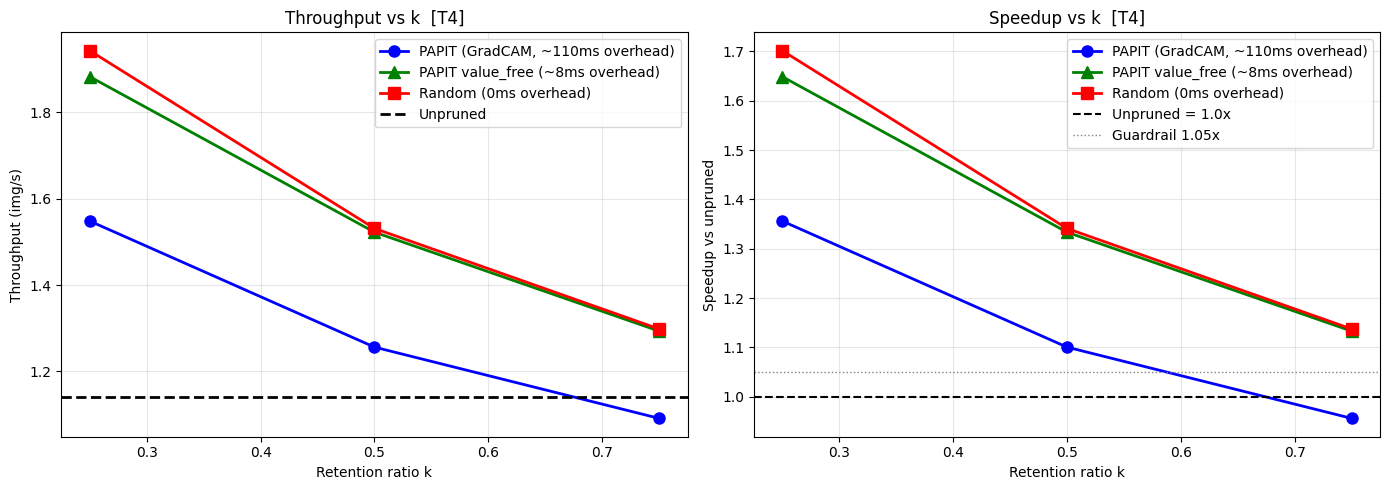

In [12]:
# Cell 11 — Plot: speedup vs retention ratio (all 3 scored variants)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

VARIANTS = [
    ('papit',       'b-o', 'PAPIT (GradCAM, ~110ms overhead)'),
    ('value_free',  'g-^', 'PAPIT value_free (~8ms overhead)'),
    ('random',      'r-s', 'Random (0ms overhead)'),
]

ax = axes[0]
for variant, style, label in VARIANTS:
    sub = summary_df[summary_df['variant'] == variant].sort_values('retention_ratio')
    ax.plot(sub['retention_ratio'], sub['throughput_img_per_sec'],
            style, label=label, linewidth=2, markersize=8)
base_tp = summary_df.loc[(summary_df['variant'] == 'unpruned'), 'throughput_img_per_sec'].values[0]
ax.axhline(base_tp, color='black', linestyle='--', linewidth=2, label='Unpruned')
ax.set_xlabel('Retention ratio k'); ax.set_ylabel('Throughput (img/s)')
ax.set_title(f'Throughput vs k  [{GPU_TAG}]'); ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for variant, style, label in VARIANTS:
    sub = summary_df[summary_df['variant'] == variant].sort_values('retention_ratio')
    ax2.plot(sub['retention_ratio'], sub['speedup_vs_unpruned'],
             style, label=label, linewidth=2, markersize=8)
ax2.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Unpruned = 1.0x')
ax2.axhline(1.05, color='gray', linestyle=':', linewidth=1, label='Guardrail 1.05x')
ax2.set_xlabel('Retention ratio k'); ax2.set_ylabel('Speedup vs unpruned')
ax2.set_title(f'Speedup vs k  [{GPU_TAG}]'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = OUTPUT_ROOT / 'throughput_vs_retention.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Figure saved to:', fig_path)
plt.show()

Figure saved to: /content/drive/MyDrive/papit_runs/T4_vf/latency_bars.png


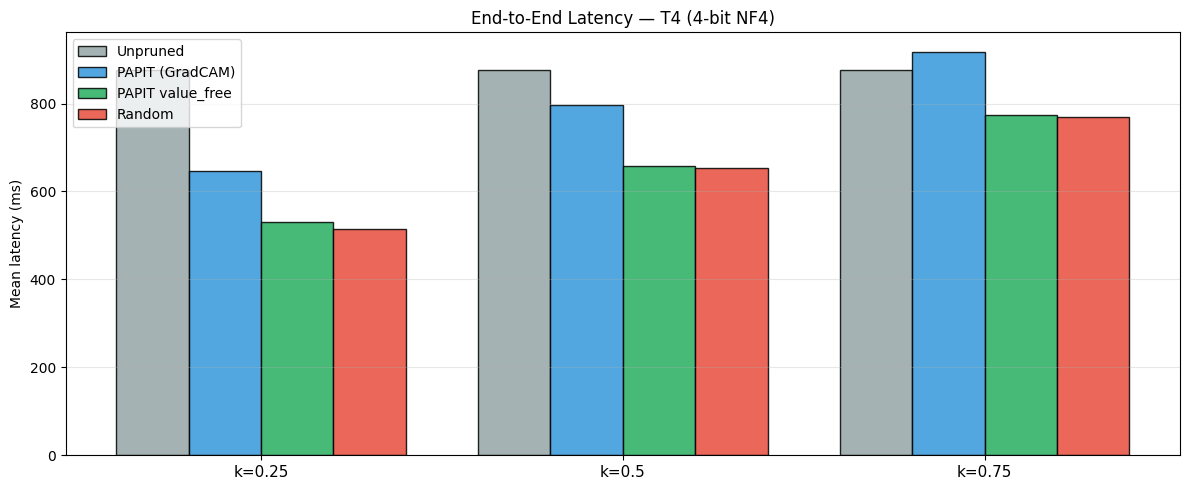

In [13]:
# Cell 12 — Bar chart: mean latency breakdown
fig, ax = plt.subplots(figsize=(12, 5))

retention_vals = sorted(r for r in set(summary_df['retention_ratio']) if r < 1.0)
bar_width = 0.20
x = np.arange(len(retention_vals))

palette = [
    ('unpruned',   '#95a5a6', 'Unpruned'),
    ('papit',      '#3498db', 'PAPIT (GradCAM)'),
    ('value_free', '#27ae60', 'PAPIT value_free'),
    ('random',     '#e74c3c', 'Random'),
]

for i, (variant, color, label) in enumerate(palette):
    sub = summary_df[summary_df['variant'] == variant].sort_values('retention_ratio')
    vals = []
    for rv in retention_vals:
        row = sub[sub['retention_ratio'] == rv]
        if not row.empty:
            vals.append(float(row['mean_end_to_end_sec'].values[0]) * 1000)
        else:
            base = summary_df.loc[summary_df['variant'] == 'unpruned', 'mean_end_to_end_sec'].values[0]
            vals.append(float(base) * 1000)
    ax.bar(x + i * bar_width, vals, bar_width, label=label, color=color,
           edgecolor='black', alpha=0.85)

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels([f'k={v}' for v in retention_vals], fontsize=11)
ax.set_ylabel('Mean latency (ms)')
ax.set_title(f'End-to-End Latency — {GPU_TAG} (4-bit NF4)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig2_path = OUTPUT_ROOT / 'latency_bars.png'
fig.savefig(fig2_path, dpi=150, bbox_inches='tight')
print('Figure saved to:', fig2_path)
plt.show()

In [14]:
# Cell 13 — Deployment decision (check both papit and value_free)
import json

MIN_SPEEDUP   = 1.05
MAX_P95_RATIO = 1.02

decisions = {}
for variant in ['papit', 'value_free']:
    print('\n' + '='*65)
    print(f'  DEPLOYMENT DECISION — {variant.upper()}')
    print(f'  Guardrails: speedup >= {MIN_SPEEDUP}  AND  p95 ratio <= {MAX_P95_RATIO}')
    print('='*65)
    best = None
    rows = summary_df[(summary_df['variant'] == variant) &
                      (summary_df['retention_ratio'] < 1.0)].sort_values(
                          'retention_ratio', ascending=False)
    for _, row in rows.iterrows():
        sp   = row['speedup_vs_unpruned']
        p95r = row['p95_ratio_vs_unpruned']
        k    = row['retention_ratio']
        ok   = sp >= MIN_SPEEDUP and p95r <= MAX_P95_RATIO
        flag = '[ELIGIBLE]' if ok else '[FAIL]    '
        print(f'  k={k:.2f}  speedup={sp:.3f}  p95_ratio={p95r:.3f}  {flag}')
        if ok and best is None:
            best = (k, sp)
    if best:
        print(f'\n  Decision: DEPLOY at k={best[0]}  (speedup={best[1]:.3f}x)')
    else:
        print(f'\n  Decision: NO point met guardrails.')
    decisions[variant] = {'k': best[0], 'speedup': best[1]} if best else None

dec_path = OUTPUT_ROOT / 'deployment_decision.json'
with open(dec_path, 'w') as f:
    json.dump({'gpu': GPU_TAG, 'use_4bit': USE_4BIT, 'decisions': decisions}, f, indent=2)
print('\nDecision saved to:', dec_path)


  DEPLOYMENT DECISION — PAPIT
  Guardrails: speedup >= 1.05  AND  p95 ratio <= 1.02
  k=0.75  speedup=0.956  p95_ratio=1.055  [FAIL]    
  k=0.50  speedup=1.100  p95_ratio=0.932  [ELIGIBLE]
  k=0.25  speedup=1.356  p95_ratio=0.749  [ELIGIBLE]

  Decision: DEPLOY at k=0.5  (speedup=1.100x)

  DEPLOYMENT DECISION — VALUE_FREE
  Guardrails: speedup >= 1.05  AND  p95 ratio <= 1.02
  k=0.75  speedup=1.133  p95_ratio=0.878  [ELIGIBLE]
  k=0.50  speedup=1.333  p95_ratio=0.750  [ELIGIBLE]
  k=0.25  speedup=1.649  p95_ratio=0.629  [ELIGIBLE]

  Decision: DEPLOY at k=0.75  (speedup=1.133x)

Decision saved to: /content/drive/MyDrive/papit_runs/T4_vf/deployment_decision.json


In [15]:
# Cell 14 — Report data summary (copy-paste ready)
print('=' * 70)
print(f'  THROUGHPUT EVAL — value_free  |  GPU: {GPU_TAG}  |  USE_4BIT: {USE_4BIT}')
print('=' * 70)

props    = torch.cuda.get_device_properties(0)
gpu_name = torch.cuda.get_device_name(0)
vram_gb  = round(props.total_memory / 1e9, 1)

print(f'\n[1] HARDWARE')
print(f'  GPU      : {gpu_name}  ({vram_gb} GB VRAM)')
print(f'  LLaVA    : {LLAVA_MODEL_ID}')
print(f'  CLIP     : {CLIP_MODEL_ID}')
print(f'  Quant    : {"4-bit NF4" if USE_4BIT else "fp16"}')
print(f'  N images : {MAX_IMAGES}  |  timed runs: {TIMED_RUNS}  |  warmup: {WARMUP_RUNS}')

unpruned_row = summary_df[(summary_df['variant'] == 'unpruned')].iloc[0]
print(f'\n[2] UNPRUNED BASELINE')
print(f'  Mean : {unpruned_row["mean_end_to_end_sec"]*1000:.1f} ms')
print(f'  P95  : {unpruned_row["p95_end_to_end_sec"]*1000:.1f} ms')
print(f'  img/s: {unpruned_row["throughput_img_per_sec"]:.3f}')

print(f'\n[3] FULL RESULTS TABLE')
print(f'  {"k":6}  {"variant":12}  {"mean_ms":>9}  {"ci_ms":>7}  {"p95_ms":>9}  {"speedup":>8}  {"saved_ms":>9}')
print(f'  {"-"*6}  {"-"*12}  {"-"*9}  {"-"*7}  {"-"*9}  {"-"*8}  {"-"*9}')
for _, row in summary_df.sort_values(['retention_ratio', 'variant'], ascending=[False, True]).iterrows():
    mean_ms  = row['mean_end_to_end_sec'] * 1000
    p95_ms   = row['p95_end_to_end_sec'] * 1000
    ci_ms    = row['ci95_ms']
    speedup  = row['speedup_vs_unpruned']
    saved_ms = (unpruned_row['mean_end_to_end_sec'] - row['mean_end_to_end_sec']) * 1000
    print(f'  {row["retention_ratio"]:<6.2f}  {row["variant"]:12}  {mean_ms:>9.1f}  +{ci_ms:>6.1f}  {p95_ms:>9.1f}  {speedup:>8.3f}  {saved_ms:>+9.1f}')

print(f'\n[4] value_free vs papit GAP (CLIP scoring overhead eliminated)')
print(f'  {"k":6}  {"papit_ms":>9}  {"vf_ms":>9}  {"gap_ms":>8}  {"vf_speedup":>10}')
for k in sorted([r for r in set(summary_df['retention_ratio']) if r < 1.0], reverse=True):
    p_row = summary_df[(summary_df['variant'] == 'papit') & (summary_df['retention_ratio'] == k)]
    v_row = summary_df[(summary_df['variant'] == 'value_free') & (summary_df['retention_ratio'] == k)]
    if not p_row.empty and not v_row.empty:
        p_ms = p_row['mean_end_to_end_sec'].values[0] * 1000
        v_ms = v_row['mean_end_to_end_sec'].values[0] * 1000
        v_sp = v_row['speedup_vs_unpruned'].values[0]
        print(f'  {k:<6.2f}  {p_ms:>9.1f}  {v_ms:>9.1f}  {v_ms-p_ms:>+8.1f}  {v_sp:>10.3f}x')

  THROUGHPUT EVAL — value_free  |  GPU: T4  |  USE_4BIT: True

[1] HARDWARE
  GPU      : Tesla T4  (15.6 GB VRAM)
  LLaVA    : llava-hf/llava-1.5-7b-hf
  CLIP     : openai/clip-vit-large-patch14
  Quant    : 4-bit NF4
  N images : 100  |  timed runs: 5  |  warmup: 3

[2] UNPRUNED BASELINE
  Mean : 875.9 ms
  P95  : 904.0 ms
  img/s: 1.142

[3] FULL RESULTS TABLE
  k       variant         mean_ms    ci_ms     p95_ms   speedup   saved_ms
  ------  ------------  ---------  -------  ---------  --------  ---------
  1.00    unpruned          875.9  +  14.0      904.0     1.000       +0.0
  0.75    papit             916.1  +  20.2      953.8     0.956      -40.2
  0.75    random            770.2  +  12.5      796.5     1.137     +105.7
  0.75    value_free        773.1  +  13.0      793.7     1.133     +102.8
  0.50    papit             795.9  +  13.0      842.1     1.100      +80.0
  0.50    random            653.1  +  11.9      678.5     1.341     +222.8
  0.50    value_free        656.9  